In [ ]:
!pip install pgmpy


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: C:\Users\Aditya\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [4]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
import networkx as nx
import pylab as plt

In [6]:
# Defining Bayesian Structure
model = DiscreteBayesianNetwork([
    ('Guest', 'Host'),
    ('Price', 'Host')
])

In [7]:
# Defining the CPDs

cpd_guest = TabularCPD(
    'Guest',
    3,
    [[0.33],
     [0.33],
     [0.33]]
)

cpd_price = TabularCPD(
    'Price',
    3,
    [[0.33],
     [0.33],
     [0.33]]
)

cpd_host = TabularCPD(
    'Host',
    3,
    [[0, 0, 0, 0, 0.5, 1, 0, 1, 0.5],
     [0.5, 0, 1, 0, 0, 0, 1, 0, 0.5],
     [0.5, 1, 0, 1, 0.5, 0, 0, 0, 0]],
    evidence=['Guest', 'Price'],
    evidence_card=[3,3]
)

In [8]:
model.add_cpds(
    cpd_guest,
    cpd_price,
    cpd_host
)

In [9]:
model.check_model()

True

In [10]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(model)

posterior_p = infer.query(
    ['Host'],
    evidence={
        'Guest':2,
        'Price':2
    }
)

print(posterior_p)

C:\Users\Aditya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


+---------+-------------+
| Host    |   phi(Host) |
+=========+=============+
| Host(0) |      0.5000 |
+---------+-------------+
| Host(1) |      0.5000 |
+---------+-------------+
| Host(2) |      0.0000 |
+---------+-------------+


In [11]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(model)

posterior_p = infer.query(
    ['Host'],
    evidence={
        'Guest':1,
        'Price':2
    }
)

print(posterior_p)

+---------+-------------+
| Host    |   phi(Host) |
+=========+=============+
| Host(0) |      1.0000 |
+---------+-------------+
| Host(1) |      0.0000 |
+---------+-------------+
| Host(2) |      0.0000 |
+---------+-------------+


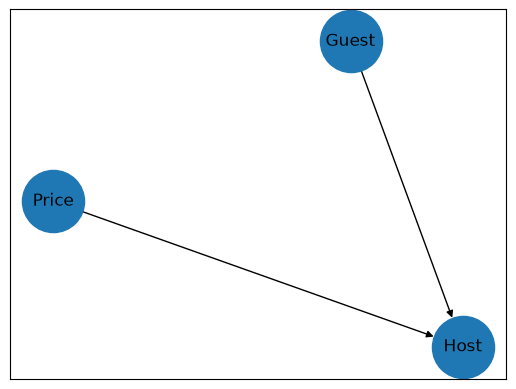

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

G.add_edges_from([
    ("Guest", "Host"),
    ("Price", "Host")
])

# Fixed positions
pos = {
    "Guest": (0, 1),
    "Price": (0, 0),
    "Host": (1, 0.5)
}

plt.figure(figsize=(6,4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    arrows=True
)

plt.show()